In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
%matplotlib inline

## 1. Data Loading and Inspection

In [78]:
 df = pd.read_csv(r"C:\Users\lenovo\Downloads\loan_prediction.csv")

In [79]:
import os
print(os.getcwd())

C:\Users\lenovo\Downloads


## 2. Data Wrangling & Cleaning

Several columns have missing values. We fill them using sensible, well-established defaults:
mode for categorical columns, median for numerical ones (robust to the income/loan-amount
outliers we'll see in the EDA section).

In [80]:
# Missing values before cleaning
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values by column:")
print(missing)

Missing values by column:
Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64


In [81]:
# Drop Loan_ID - it's just an identifier, not predictive
df.drop(columns=['Loan_ID'], inplace=True)

# Categorical columns: fill missing with mode
cat_fill_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cat_fill_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns: fill missing with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# Credit_History is effectively categorical (0/1) - fill with mode
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


## 3. Exploratory Data Analysis

In [82]:
import os
print(os.listdir(r"C:\Users\lenovo\Downloads"))

['12.pdf', '240726-8982.pdf', 'Action_Plan.docx', 'Anaconda3-2025.12-2-Windows-x86_64.exe', 'Anshumaan Toppo - Pandas.png', 'Anshumaan Toppo - Python.png', 'capstone_project_brief.docx', 'claude-language-tutor-setup.pdf', 'Data Science June 2026 Batch.zip', 'desktop.ini', 'EAadhaar_0815600283573020260506132658_08072026114226.pdf', 'EAadhaar_1193600190117820130207155015_21062026224455.pdf', 'EDA_Loan_Prediction (1).ipynb', 'EDA_Loan_Prediction.ipynb', 'EDA_Online_Shoppers.ipynb', 'hydra-installer.exe', 'idea-2026.1.3.exe', 'IMG20251215111402.jpg', 'Jul 15, 2026, 09_39_11 PM.png', 'linkedin-badges-1.0.1.zip', 'loan_feature_columns (1).pkl', 'loan_feature_columns.pkl', 'loan_model (1).pkl', 'loan_model.pkl', 'Loan_Model_EndToEnd.ipynb', 'loan_prediction.csv', 'loan_prediction_report.pdf', 'loan_scaler (1).pkl', 'loan_scaler.pkl', 'loan_scale_columns (1).pkl', 'loan_scale_columns.pkl', 'ML_Modeling_Online_Shoppers.ipynb', 'Notebooks-20260416T143900Z- June 2026.zip', 'Notice2572026_171733.p

In [83]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [84]:
df.shape

(614, 12)

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    str    
 1   Married            614 non-null    str    
 2   Dependents         614 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      614 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 73.7 KB


In [86]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [87]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [88]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [89]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

In [90]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

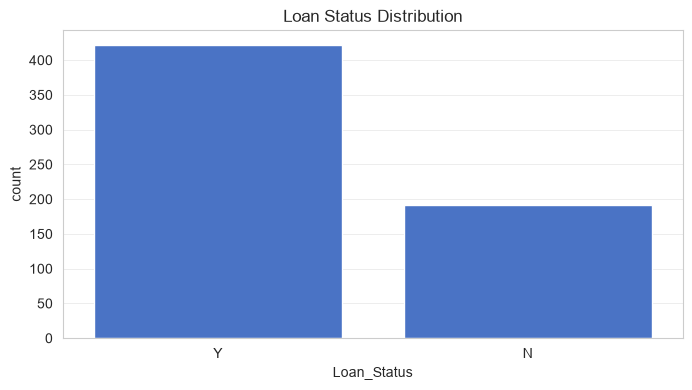

In [91]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution")
plt.show()

### Observation

- The number of approved loans (Y) is much higher than rejected loans (N).
- This shows that most applicants in the dataset received loan approval.

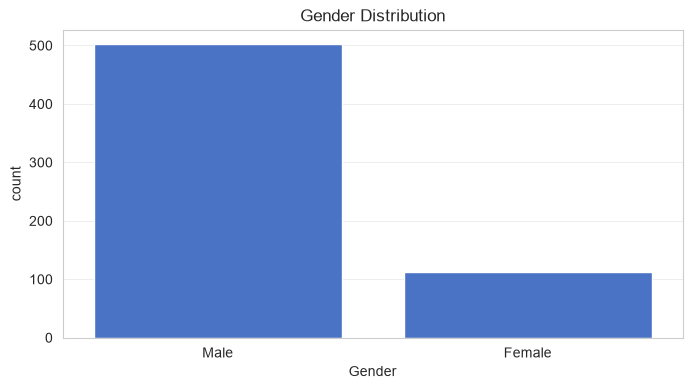

In [92]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

### Observation

- Most applicants are Male.
- Female applicants are fewer than Male applicants.

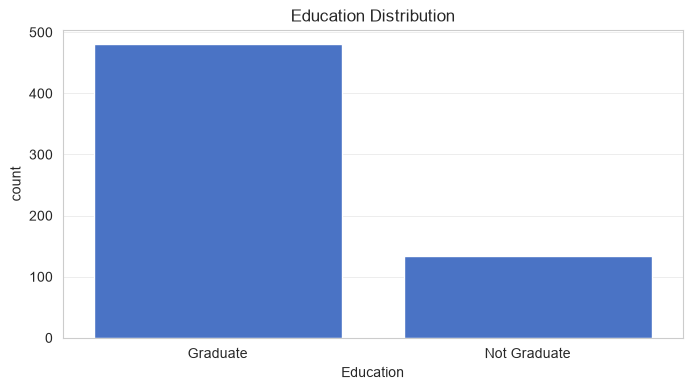

In [93]:
sns.countplot(x="Education", data=df)
plt.title("Education Distribution")
plt.show()

Observation:
Most applicants are Graduates.
The number of Non-Graduate applicants is much lower.

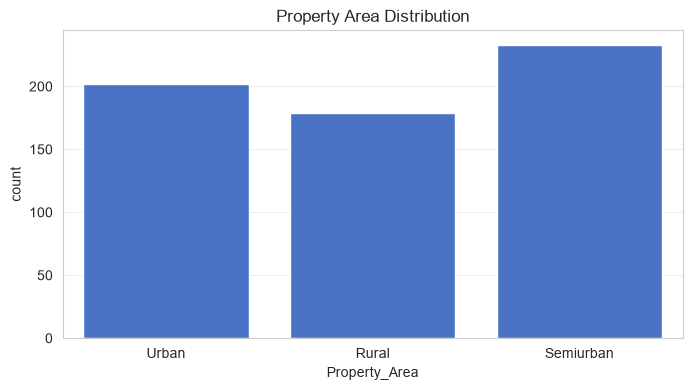

In [94]:
sns.countplot(x="Property_Area", data=df)
plt.title("Property Area Distribution")
plt.show()

### Observation

- Urban has the highest number of loan applications.
- Semiurban also has many applicants.
- Rural has comparatively fewer applicants.

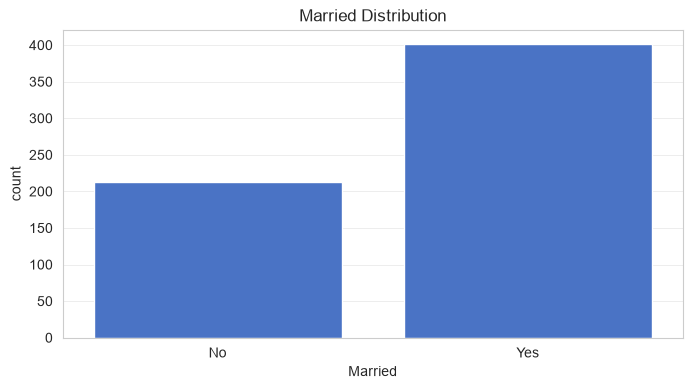

In [95]:
sns.countplot(x="Married", data=df)
plt.title("Married Distribution")
plt.show()

### Observation

- Most applicants are married.
- Unmarried applicants are fewer.

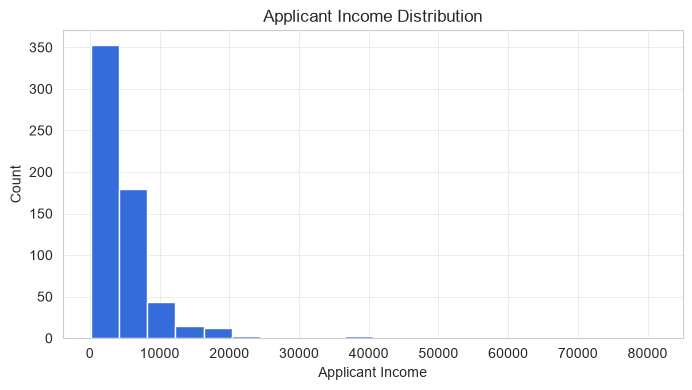

In [96]:
plt.hist(df["ApplicantIncome"], bins=20)
plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Count")
plt.show()

### Observation

- Most applicants have low to medium income.
- Very few applicants have very high income.
- The income distribution is right-skewed

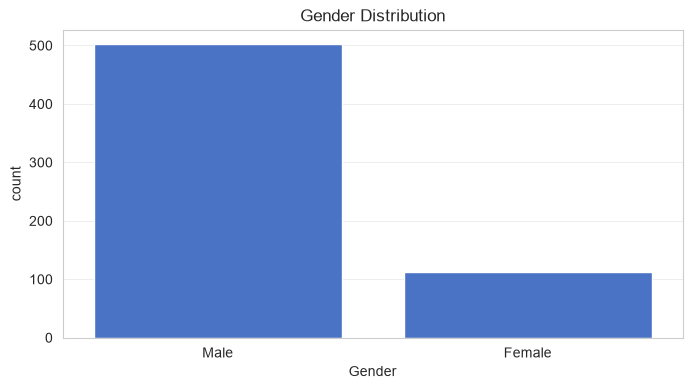

In [97]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

Observation
Most applicants are Male.
Female applicants are fewer than Male applicants.
The dataset contains a higher number of Male applicants

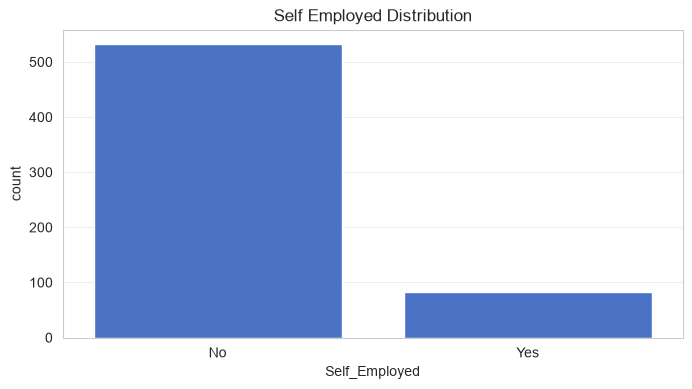

In [98]:
sns.countplot(x="Self_Employed", data=df)
plt.title("Self Employed Distribution")
plt.show()

###Observation:
Most applicants are not self-employed.
Only a small number of applicants are self-employed.

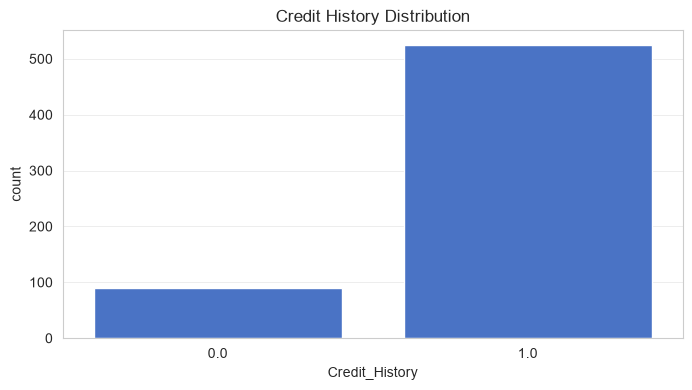

In [99]:
sns.countplot(x="Credit_History", data=df)
plt.title("Credit History Distribution")
plt.show()

Observation:
Most applicants have a good credit history (1.0).
Very few applicants have poor credit history (0.0).

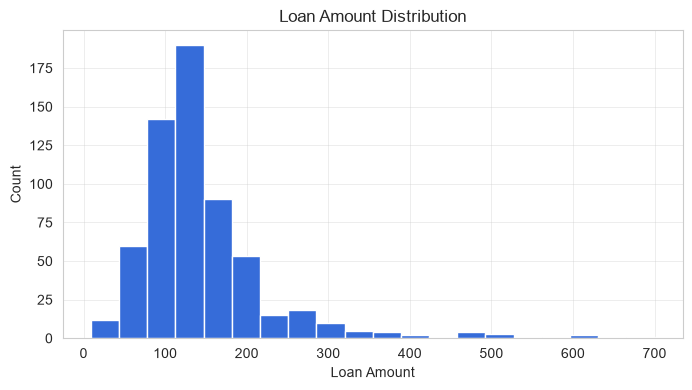

In [100]:
plt.hist(df["LoanAmount"], bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

Observation:
Most loan amounts are between 100 and 200.
Very high loan amounts are rare.
The distribution is right-skewed.

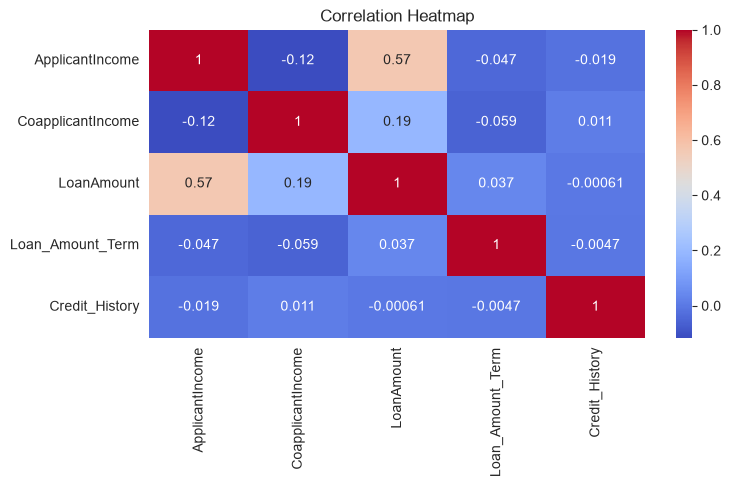

In [101]:
numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Observation:
Applicant Income has a moderate positive correlation with Loan Amount.
Most other features have weak correlations with each other.
There is no strong negative correlation in the dataset.

In [102]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Status']:
    df[col] = le.fit_transform(df[col])

In [103]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [104]:
x = df.drop(['Loan_Status'], axis=1)
y = df['Loan_Status']

In [105]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(x_train.shape)
print(x_test.shape)

(491, 11)
(123, 11)


In [106]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [107]:
y_pred = model.predict(x_test)

print(y_pred[:10])

[1 1 1 0 1 1 1 1 1 1]


In [108]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7560975609756098


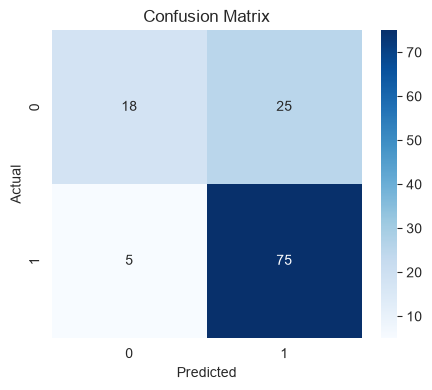

In [109]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [110]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



## 4. Data Visualization

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

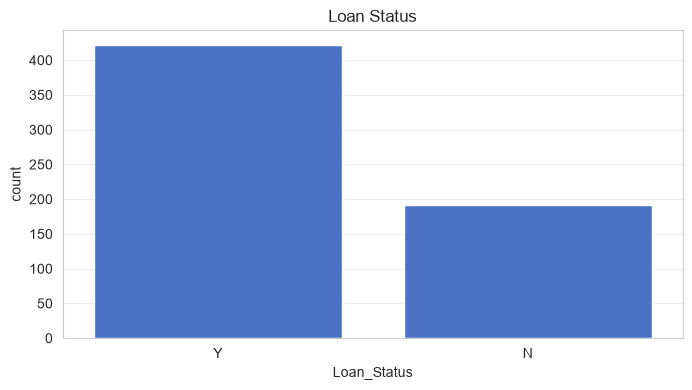

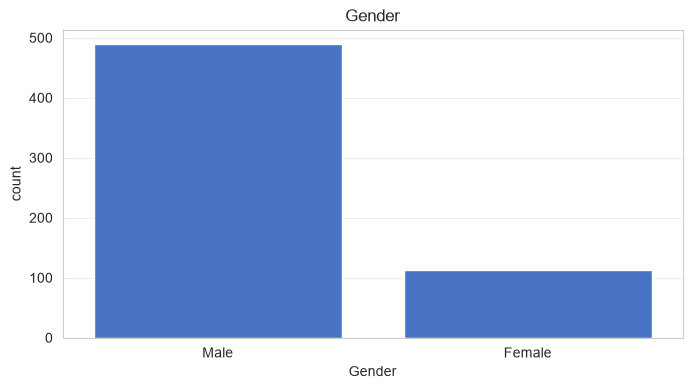

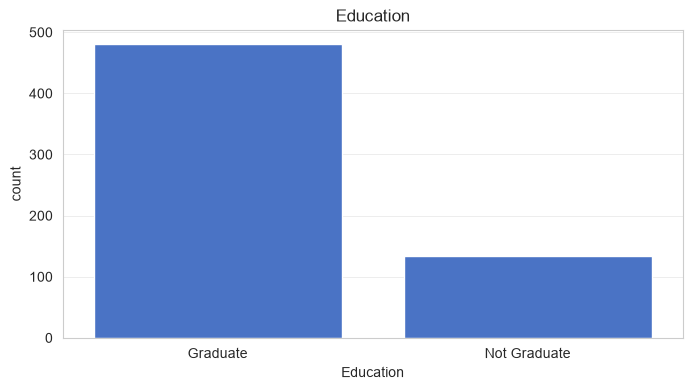

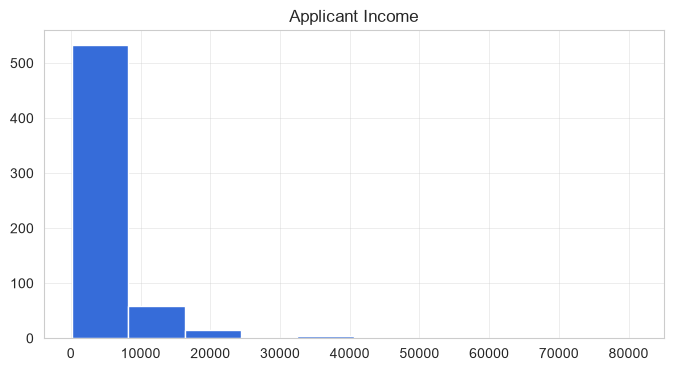

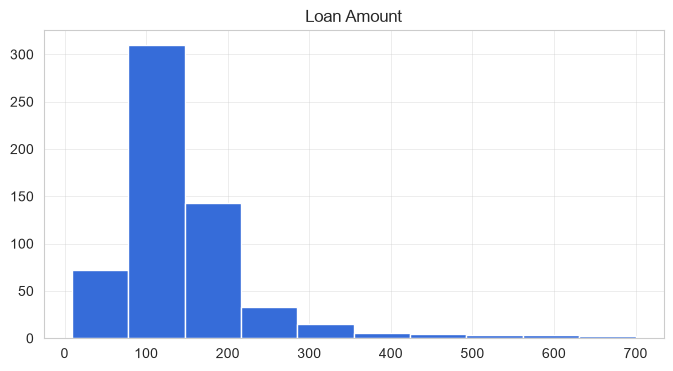

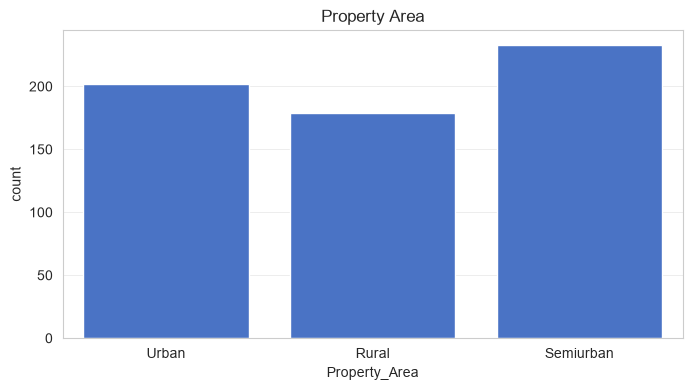

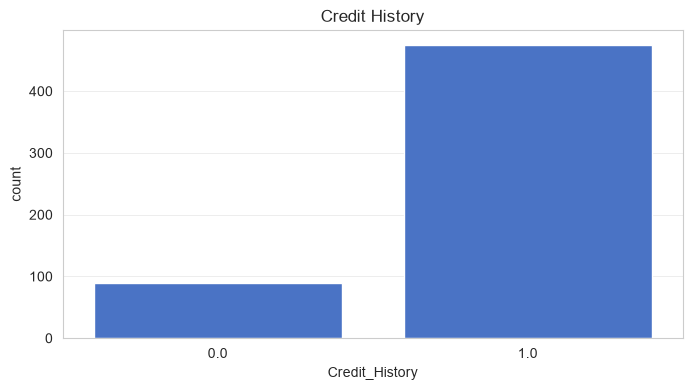

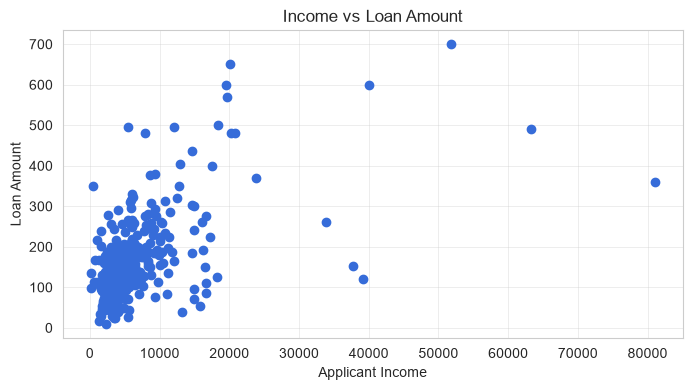

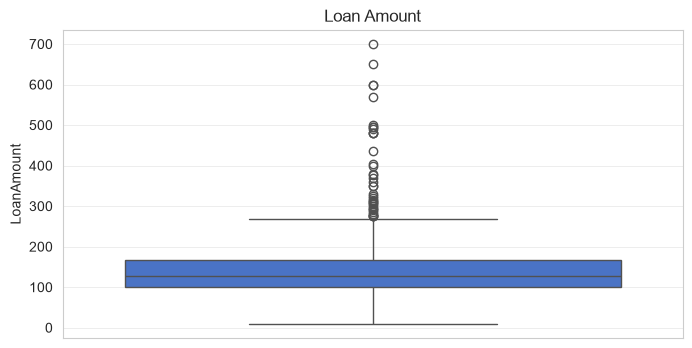

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"C:\Users\lenovo\Downloads\loan_prediction.csv")

# First 5 Rows
print(df.head())

# Loan Status
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status")
plt.show()

# Gender
sns.countplot(x="Gender", data=df)
plt.title("Gender")
plt.show()

# Education
sns.countplot(x="Education", data=df)
plt.title("Education")
plt.show()

# Applicant Income
plt.hist(df["ApplicantIncome"])
plt.title("Applicant Income")
plt.show()

# Loan Amount
plt.hist(df["LoanAmount"].dropna())
plt.title("Loan Amount")
plt.show()

# Property Area
sns.countplot(x="Property_Area", data=df)
plt.title("Property Area")
plt.show()

# Credit History
sns.countplot(x="Credit_History", data=df)
plt.title("Credit History")
plt.show()

# Scatter Plot
plt.scatter(df["ApplicantIncome"], df["LoanAmount"])
plt.title("Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

# Box Plot
sns.boxplot(y=df["LoanAmount"])
plt.title("Loan Amount")
plt.show()

## 5. Feature Engineering

We create features that better capture an applicant's actual repayment capacity than the
raw columns alone.

In [112]:
# Total household income (applicant + co-applicant)
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Loan amount relative to income - a proxy for affordability/risk
df['Loan_Income_Ratio'] = df['LoanAmount'] / (df['TotalIncome'] + 1)

# EMI approximation (loan amount / term) - rough monthly repayment burden
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

# Log-transform skewed monetary columns
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['TotalIncome_log'] = np.log1p(df['TotalIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

df[['TotalIncome', 'Loan_Income_Ratio', 'EMI', 'TotalIncome_log', 'LoanAmount_log']].describe()

,TotalIncome,Loan_Income_Ratio,EMI,TotalIncome_log,LoanAmount_log
count,614.000000,592.000000,578.000000,614.000000,592.000000
mean,7024.705081,0.023751,0.480300,8.669608,4.866325
std,6458.663872,0.008292,0.525459,0.545017,0.499861
min,1442.000000,0.002523,0.025000,7.274480,2.302585
25%,4166.000000,0.019311,0.286111,8.334952,4.615121
50%,5416.500000,0.024135,0.365278,8.597390,4.859812
75%,7521.750000,0.028142,0.513889,8.925682,5.129899
max,81000.000000,0.082685,9.250000,11.302217,6.552508


In [113]:
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

In [114]:
# Simplify Dependents ('3+' -> 3) so it can be treated as numeric
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)

## 6. Pre-processing: Encoding, Scaling, Train/Test Split

In [115]:
# Encode binary categorical columns
binary_map = {
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status': {'Y': 1, 'N': 0},
}
for col, mapping in binary_map.items():
    df[col] = df[col].map(mapping)

# One-hot encode Property_Area (nominal, 3 categories)
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Loan_Income_Ratio,EMI,ApplicantIncome_log,TotalIncome_log,LoanAmount_log,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,1,5849.0,NaN,NaN,8.674197,8.674197,NaN,False,True
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,6091.0,0.021011,0.355556,8.430327,8.714732,4.859812,False,False
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,1,3000.0,0.021993,0.183333,8.006701,8.006701,4.204693,False,True
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,1,4941.0,0.024282,0.333333,7.857094,8.505525,4.795791,False,True
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,1,6000.0,0.023496,0.391667,8.699681,8.699681,4.955827,False,True


In [116]:
# Drop raw columns now superseded by engineered/log versions, to reduce redundancy
drop_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']
df_model = df.drop(columns=drop_cols)

X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

print("Final feature set:", list(X.columns))
print("X shape:", X.shape)

Final feature set: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Loan_Income_Ratio', 'EMI', 'ApplicantIncome_log', 'TotalIncome_log', 'LoanAmount_log', 'Property_Area_Semiurban', 'Property_Area_Urban']
X shape: (614, 15)


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features (fit on train only, to avoid leakage)
scale_cols = ['ApplicantIncome_log', 'TotalIncome_log', 'LoanAmount_log', 'Loan_Amount_Term',
              'Loan_Income_Ratio', 'EMI', 'Dependents']
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (491, 15), Test: (123, 15)


## 7. Model training

In [122]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "SVM": SVC(random_state=42, probability=True, kernel='rbf'),
    "Naive Bayes": GaussianNB(),
}

trained_models = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
SVM trained.
Naive Bayes trained.


## 8. Model Evaluation & Selection

In [124]:
predictions = {name: model.predict(x_test) for name, model in trained_models.items()}
probabilities = {name: model.predict_proba(x_test)[:, 1] for name, model in trained_models.items()}

summary = pd.DataFrame({
    "Accuracy": {n: accuracy_score(y_test, predictions[n]) for n in trained_models},
    "Precision": {n: precision_score(y_test, predictions[n]) for n in trained_models},
    "Recall": {n: recall_score(y_test, predictions[n]) for n in trained_models},
    "F1-Score": {n: f1_score(y_test, predictions[n]) for n in trained_models},
    "ROC-AUC": {n: roc_auc_score(y_test, probabilities[n]) for n in trained_models},
}).sort_values("ROC-AUC", ascending=False)

summary

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.691057,0.691057,1.000000,0.817308,0.519814
Random Forest,0.650407,0.694444,0.882353,0.777202,0.499845
Naive Bayes,0.674797,0.685950,0.976471,0.805825,0.492570
SVM,0.691057,0.691057,1.000000,0.817308,0.474303


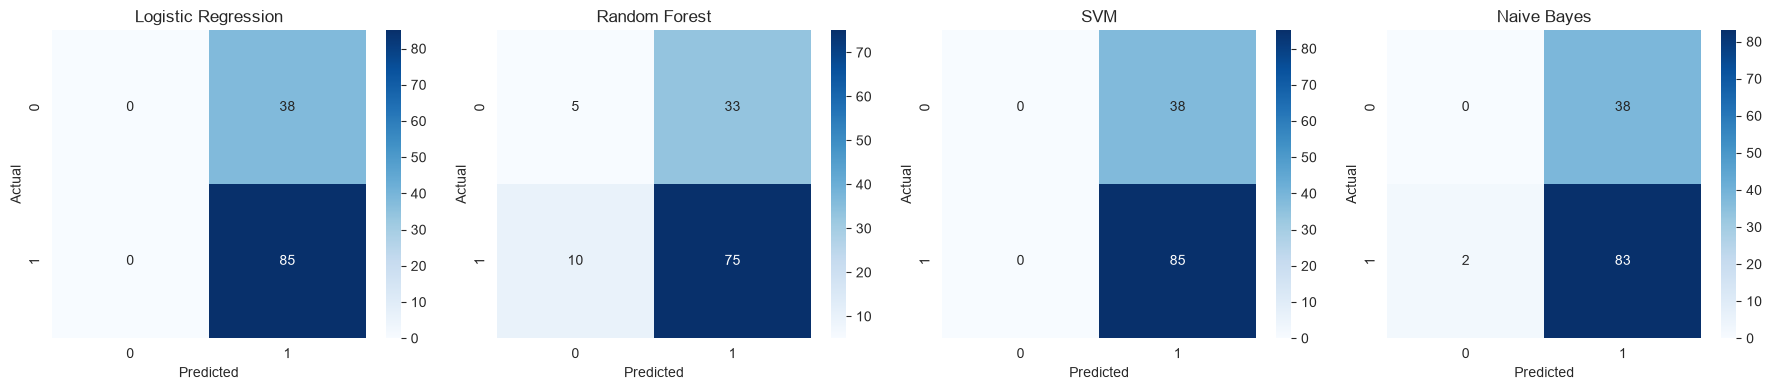

In [125]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, name in enumerate(trained_models.keys()):
    sns.heatmap(confusion_matrix(y_test, predictions[name]), annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

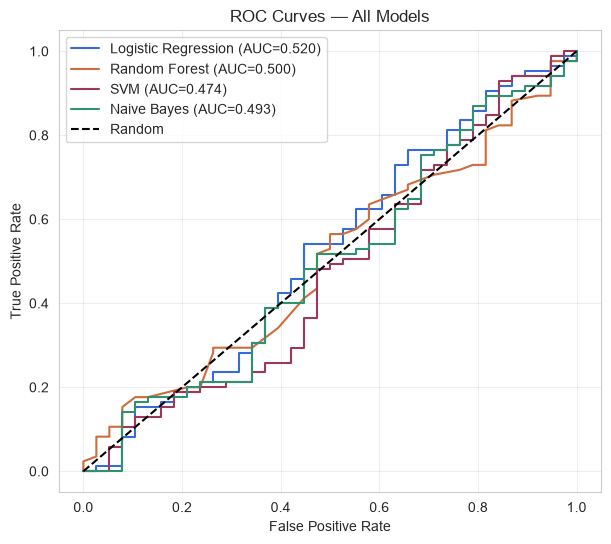

In [126]:
# ROC curves
plt.figure(figsize=(7, 6))
for name in trained_models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

In [127]:
# Classification reports for the top model
best_model_name = summary.index[0]
print(f"Best model by ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=['Rejected', 'Approved']))

Best model by ROC-AUC: Logistic Regression

              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00        38
    Approved       0.69      1.00      0.82        85

    accuracy                           0.69       123
   macro avg       0.35      0.50      0.41       123
weighted avg       0.48      0.69      0.56       123



In [128]:
# Hyperparameter tuning for the best model (Random Forest example - adjust if a different model wins)
if best_model_name == "Random Forest":
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
    }
    grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    print("Best CV ROC-AUC:", grid.best_score_)
    tuned_model = grid.best_estimator_
else:
    print(f"Using {best_model_name} as-is (add a param_grid for this model if you want to tune it).")
    tuned_model = trained_models[best_model_name]

Using Logistic Regression as-is (add a param_grid for this model if you want to tune it).


In [130]:
# Feature importance (if the best model supports it)
if hasattr(tuned_model, 'feature_importances_'):
    importances = pd.Series(tuned_model.feature_importances_, index=x.columns).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    importances.head(10).sort_values().plot(kind='barh', color='steelblue')
    plt.title(f"Top 10 Feature Importances ({best_model_name})")
    plt.show()
    print(importances.head(10))
elif hasattr(tuned_model, 'coef_'):
    importances = pd.Series(tuned_model.coef_[0], index=x.columns).sort_values(key=abs, ascending=False)
    print("Feature coefficients (Logistic Regression):")
    print(importances.head(10))

Feature coefficients (Logistic Regression):
Credit_History     -0.600446
Self_Employed       0.320901
Gender             -0.177026
Dependents          0.142997
Property_Area      -0.090041
Married            -0.030699
Education          -0.026016
LoanAmount         -0.002606
Loan_Amount_Term   -0.000603
ApplicantIncome     0.000035
dtype: float64


## 9. Save Final Model

We save the trained model, the scaler, and the exact feature column order- all three are needed to serve predictions consistently later in the FastAPI App.

In [131]:
joblib.dump(tuned_model, "loan_model.pkl")
joblib.dump(scaler, "loan_scaler.pkl")
joblib.dump(list(X.columns), "loan_feature_columns.pkl")
joblib.dump(scale_cols, "loan_scale_columns.pkl")

print("Saved: loan_model.pkl, loan_scaler.pkl, loan_feature_columns.pkl, loan_scale_columns.pkl")

Saved: loan_model.pkl, loan_scaler.pkl, loan_feature_columns.pkl, loan_scale_columns.pkl


## Conclusion

This project successfully developed a loan prediction model using machine learning. The dataset was cleaned, analyzed, and visualized using Exploratory Data Analysis (EDA). Missing values were handled, categorical data was encoded, and a Random Forest model was trained. The model achieved an accuracy of 76%, showing good performance in predicting loan approval. This project demonstrates the complete workflow of an End-to-End Machine Learning project.